In [1]:
from pvlib.iotools import read_epw # Importar la función para leer archivos EPW
import pandas as pd # Importar pandas para manipulación de datos

In [2]:
# Leer el archivo EPW
data, metadata = read_epw("data/MEX_YUC_Merida-Rejon.Intl.AP.766440_TMYx.2011-2025.epw")
data

,year,month,day,hour,minute,data_source_unct,temp_air,temp_dew,relative_humidity,atmospheric_pressure,...,ceiling_height,present_weather_observation,present_weather_codes,precipitable_water,aerosol_optical_depth,snow_depth,days_since_last_snowfall,albedo,liquid_precipitation_depth,liquid_precipitation_quantity
2022-01-01 00:00:00-06:00,2022,1,1,1,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,23.0,22.0,94,101190,...,77777,0,919999999,87,0.085,0,88,0.14,0.0,0.0
2022-01-01 01:00:00-06:00,2022,1,1,2,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,23.0,22.0,94,101190,...,77777,0,919999999,87,0.085,0,88,0.14,0.0,0.0
2022-01-01 02:00:00-06:00,2022,1,1,3,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,22.0,21.0,94,101189,...,77777,0,919999999,78,0.085,0,88,0.14,0.0,0.0
2022-01-01 03:00:00-06:00,2022,1,1,4,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,22.0,21.0,94,101189,...,498,0,919999999,78,0.085,0,88,0.14,0.0,0.0
2022-01-01 04:00:00-06:00,2022,1,1,5,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,23.0,22.0,94,101190,...,457,0,919999999,87,0.085,0,88,0.14,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00-06:00,2022,12,31,20,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9?9?9*9*9?9*9,27.0,22.0,74,101191,...,2134,9,999999999,86,0.085,0,88,0.14,0.0,0.0
2022-12-31 20:00:00-06:00,2022,12,31,21,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,27.0,23.0,79,101596,...,9144,9,999999999,95,0.085,0,88,0.14,0.0,0.0
2022-12-31 21:00:00-06:00,2022,12,31,22,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9?9?9*9*9?9*9,26.8,24.7,88,101446,...,77777,9,999999999,113,0.085,0,88,0.14,0.0,0.0
2022-12-31 22:00:00-06:00,2022,12,31,23,0,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,25.0,22.0,83,101190,...,1049,9,999999999,86,0.085,0,88,0.14,0.0,0.0


In [ ]:
data = data.sort_index()
Tai = data.To["2026-05-01":"2026-05-31"].resample("D").max().mean()
print(f"La temperatura máxima diaria media mensual del mes con la temperatura media más alta es: {Tai}")

In [4]:
ground_temp_info = metadata.get("GROUND TEMPERATURES")
print(ground_temp_info)

None


In [5]:
metadata.keys()

dict_keys(['loc', 'city', 'state-prov', 'country', 'data_type', 'WMO_code', 'latitude', 'longitude', 'TZ', 'altitude'])

In [14]:
mes = data.temp_air.resample("ME").mean().idxmax().month # calcular la media mensual de la temperatura exterior (To) y obtener el mes con la temperatura media más alta
print(f"El mes con la temperatura media más alta es: {mes}")

El mes con la temperatura media más alta es: 5


In [15]:
# 2. Filter the hourly dataset strictly for the month of May (Month = 5)
may_hourly = data[data.index.month == mes]

# 3. Calculate the mean (average) temperature for each individual day in May
may_daily_means = may_hourly['temp_air'].resample('D').mean()

# 4. Find the maximum value among those daily averages
max_mean_daily_may = may_daily_means.max()

print(f"Max Mean Daily Temperature of May: {max_mean_daily_may:.2f} °C")


Max Mean Daily Temperature of May: 31.95 °C


In [16]:
Tai = data[data.index.month == mes].temp_air.resample("D").max().mean()
Tai

np.float64(37.1741935483871)

In [17]:
import pandas as pd

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ground_data = {}

with open('data/MEX_YUC_Merida-Rejon.Intl.AP.766440_TMYx.2011-2025.epw', 'r') as f:
    for line in f:
        if line.startswith('DATA PERIODS'):
            break
            
        if line.startswith('GROUND TEMPERATURES'):
            parts = line.strip().split(',')
            
            # Index 0 is 'GROUND TEMPERATURES', Index 1 is the number of depths ('3')
            # Extract all tokens after those metadata labels
            tokens = parts[2:]
            
            i = 0
            while i < len(tokens):
                if tokens[i] == '':
                    i += 1
                    continue
                
                # 1. Read the depth value (e.g., 0.5, 2.0, 4.0)
                depth = float(tokens[i])
                
                # 2. Skip the depth field + 3 empty soil property columns (4 fields total)
                i += 4 
                
                # 3. Read the next 12 sequential monthly values
                monthly_values = []
                for _ in range(12):
                    monthly_values.append(float(tokens[i]))
                    i += 1
                
                # 4. Save to the tracking dictionary
                ground_data[f"{depth}m"] = monthly_values

# Compile into a clean DataFrame
df_ground = pd.DataFrame(ground_data, index=months)
print(df_ground)


      0.5m   2.0m   4.0m
Jan  24.28  25.23  26.01
Feb  24.02  24.77  25.54
Mar  24.48  24.86  25.44
Apr  25.20  25.24  25.58
May  27.06  26.49  26.29
Jun  28.51  27.62  27.05
Jul  29.48  28.53  27.75
Aug  29.77  29.01  28.23
Sep  29.27  28.91  28.35
Oct  28.15  28.27  28.07
Nov  26.65  27.24  27.47
Dec  25.27  26.15  26.73


In [18]:
# [Keep your existing code above that generates df_ground here]

# 1. Calculate the annual mean temperature for each depth
mean_temps = df_ground.mean()

# 2. Calculate the max yearly variation (Maximum month - Minimum month)
yearly_variation = df_ground.max() - df_ground.min()

# 3. Display the results in a clean table format
df_summary = pd.DataFrame({
    'Annual Mean (°C)': mean_temps,
    'Max Variation (°C)': yearly_variation
})

print("\n--- Ground Temperature Statistics ---")
print(df_summary.round(2))



--- Ground Temperature Statistics ---
      Annual Mean (°C)  Max Variation (°C)
0.5m             26.84                5.75
2.0m             26.86                4.24
4.0m             26.88                2.91


In [19]:
import pandas as pd

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ground_data = {}

with open('data/MEX_YUC_Merida-Rejon.Intl.AP.766440_TMYx.2011-2025.epw', 'r') as f:
    for line in f:
        if line.startswith('DATA PERIODS'):
            break
            
        if line.startswith('GROUND TEMPERATURES'):
            parts = line.strip().split(',')
            tokens = parts[2:]
            
            i = 0
            while i < len(tokens):
                if tokens[i] == '':
                    i += 1
                    continue
                
                depth = float(tokens[i])
                i += 4 
                
                monthly_values = []
                for _ in range(12):
                    monthly_values.append(float(tokens[i]))
                    i += 1
                
                ground_data[f"{depth}m"] = monthly_values

# 1. Compile into the baseline monthly DataFrame
df_ground = pd.DataFrame(ground_data, index=months)

# 2. Calculate the statistical metrics
mean_row = df_ground.mean()
variation_row = df_ground.max() - df_ground.min()

# 3. Append the new rows to the bottom of the DataFrame
df_ground.loc['Mean'] = mean_row
df_ground.loc['Variation'] = variation_row

# Display the final unified table (rounded to 2 decimal places)
print(df_ground.round(2))


            0.5m   2.0m   4.0m
Jan        24.28  25.23  26.01
Feb        24.02  24.77  25.54
Mar        24.48  24.86  25.44
Apr        25.20  25.24  25.58
May        27.06  26.49  26.29
Jun        28.51  27.62  27.05
Jul        29.48  28.53  27.75
Aug        29.77  29.01  28.23
Sep        29.27  28.91  28.35
Oct        28.15  28.27  28.07
Nov        26.65  27.24  27.47
Dec        25.27  26.15  26.73
Mean       26.84  26.86  26.88
Variation   5.75   4.24   2.91


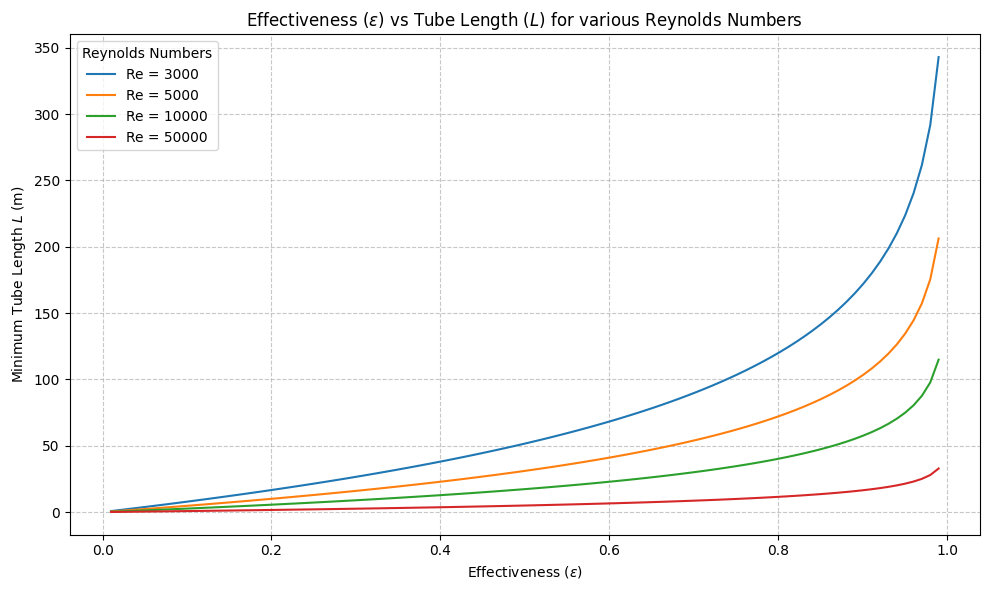

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
cp = 1.007e3 # J/kg·K
k = 2.63e-2  # W/m·K
Pr = 0.707

# NOTE: rho and Q were not defined in your snippet, using example values (e.g., air).
# Replace these with your actual system values.
rho = 1.225  # kg/m³
Q = 0.05     # m³/s 

# Array of Reynolds number values to compare
Re_values = [3000, 5000, 10000, 50000]

# Array for epsilon (effectiveness) from 0.01 to 0.99
# We avoid exactly 1.0 to prevent a math error with np.log(0)
epsilon = np.linspace(0.01, 0.99, 100)

# Setup the plot
plt.figure(figsize=(10, 6))

for Re in Re_values:
    # Cálculo de la rugosidad relativa / factor de fricción
    varepsilon = (1.82 * np.log10(Re) - 1.64) ** (-2)
    
    # Cálculo del número de Nusselt (Gnielinski correlation)
    Nu = (varepsilon / 8 * (Re - 1000) * Pr) / (1 + 12.7 * (varepsilon / 8) ** 0.5 * (Pr ** (2/3) - 1))
    
    # Cálculo de la longitud mínima del tubo L
    L = (-np.log(1 - epsilon) * cp * rho * Q) / (np.pi * Nu * k)
    
    # Plot this specific Re line
    plt.plot(epsilon, L, label=f'Re = {Re}')

# Formatting the plot
plt.xlabel(r'Effectiveness ($\epsilon$)')
plt.ylabel('Minimum Tube Length $L$ (m)')
plt.title(r'Effectiveness ($\epsilon$) vs Tube Length ($L$) for various Reynolds Numbers')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Reynolds Numbers")
plt.tight_layout()

# Display the plot
plt.show()

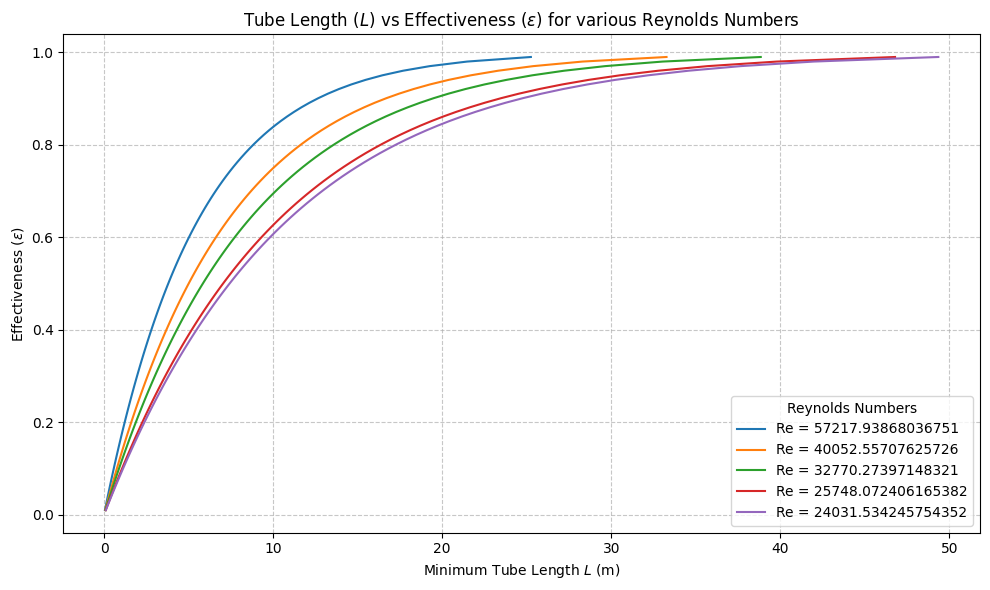

In [5]:
import numpy as np
import matplotlib.pyplot as plt

CAH = 6
V = 27 # m³
Q = CAH * V / 3600
rho = 1.1614 # kg/m³

D = np.array([0.063, 0.090, 0.110, 0.140, 0.150]) # m
A = np.pi * (D / 2) ** 2
v = Q / A
mu = 1.846e-5 # N·s/m²
Re_values = (rho * v * D) / mu

# --- Constants ---
cp = 1.007e3 # J/kg·K
k = 2.63e-2  # W/m·K
Pr = 0.707

# Array for epsilon (effectiveness) from 0.01 to 0.99
epsilon = np.linspace(0.01, 0.99, 100)

plt.figure(figsize=(10, 6))

for Re in Re_values:
    # Cálculo de la rugosidad relativa / factor de fricción
    varepsilon = (1.82 * np.log10(Re) - 1.64) ** (-2)
    
    # Cálculo del número de Nusselt (Gnielinski correlation)
    Nu = (varepsilon / 8 * (Re - 1000) * Pr) / (1 + 12.7 * (varepsilon / 8) ** 0.5 * (Pr ** (2/3) - 1))
    
    # Cálculo de la longitud mínima del tubo L
    L = (-np.log(1 - epsilon) * cp * rho * Q) / (np.pi * Nu * k)
    
    # Plot with switched axes: L on x-axis, epsilon on y-axis
    plt.plot(L, epsilon, label=f'Re = {Re}')

plt.xlabel('Minimum Tube Length $L$ (m)')
plt.ylabel(r'Effectiveness ($\epsilon$)')
plt.title(r'Tube Length ($L$) vs Effectiveness ($\epsilon$) for various Reynolds Numbers')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Reynolds Numbers")
plt.tight_layout()

# Save the plot
plt.savefig('switched_axes_plot.png')

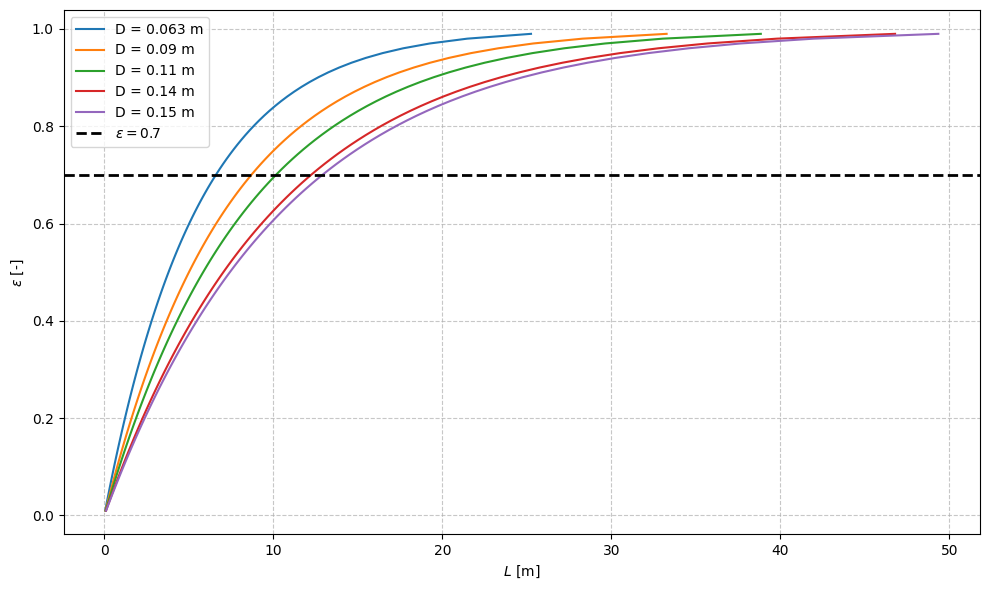

In [9]:
import numpy as np
import matplotlib.pyplot as plt

CAH = 6
V = 27 # m³
Q = CAH * V / 3600
rho = 1.1614 # kg/m³

D = np.array([0.063, 0.090, 0.110, 0.140, 0.150]) # m
A = np.pi * (D / 2) ** 2
v = Q / A
mu = 1.846e-5 # N·s/m²
Re_values = (rho * v * D) / mu

# --- Constants ---
cp = 1.007e3 # J/kg·K
k = 2.63e-2  # W/m·K
Pr = 0.707

# Array for epsilon (effectiveness) from 0.01 to 0.99
epsilon = np.linspace(0.01, 0.99, 100)

plt.figure(figsize=(10, 6))

# Iterate through both Re_values and D simultaneously
for Re, d_val in zip(Re_values, D):
    # Cálculo de la rugosidad relativa / factor de fricción
    varepsilon = (1.82 * np.log10(Re) - 1.64) ** (-2)
    
    # Cálculo del número de Nusselt (Gnielinski correlation)
    Nu = (varepsilon / 8 * (Re - 1000) * Pr) / (1 + 12.7 * (varepsilon / 8) ** 0.5 * (Pr ** (2/3) - 1))
    
    # Cálculo de la longitud mínima del tubo L
    L = (-np.log(1 - epsilon) * cp * rho * Q) / (np.pi * Nu * k)
    
    # Plot with switched axes: L on x-axis, epsilon on y-axis, label is D
    plt.plot(L, epsilon, label=f'D = {d_val} m')

# Add horizontal line at epsilon = 0.7
plt.axhline(y=0.7, color='black', linestyle='--', linewidth=2, label=r'$\epsilon = 0.7$')

plt.xlabel('$L$ [m]')
plt.ylabel(r'$\epsilon$ [-]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('epsilon_target_plot.png')